In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [2]:
df = pd.read_csv('pubg.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4348079 entries, 0 to 4348078
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          float64
 4   boosts           float64
 5   damageDealt      float64
 6   DBNOs            float64
 7   headshotKills    float64
 8   heals            float64
 9   killPlace        float64
 10  killPoints       float64
 11  kills            float64
 12  killStreaks      float64
 13  longestKill      float64
 14  matchDuration    float64
 15  matchType        object 
 16  maxPlace         float64
 17  numGroups        float64
 18  rankPoints       float64
 19  revives          float64
 20  rideDistance     float64
 21  roadKills        float64
 22  swimDistance     float64
 23  teamKills        float64
 24  vehicleDestroys  float64
 25  walkDistance     float64
 26  weaponsAcquired  float64
 27  winPoints   

In [4]:
df.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,...,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348078e+06,4.348077e+06
mean,2.338387e-01,1.106999e+00,1.307276e+02,6.579029e-01,2.268255e-01,1.370292e+00,4.759769e+01,5.049881e+02,9.249174e-01,5.439896e-01,...,1.647068e-01,6.062188e+02,3.495797e-03,4.505707e+00,2.386572e-02,7.919591e-03,1.154315e+03,3.660722e+00,6.064436e+02,4.728293e-01
std,5.886271e-01,1.715977e+00,1.708210e+02,1.145891e+00,6.023710e-01,2.680332e+00,2.746354e+01,6.274943e+02,1.558780e+00,7.109782e-01,...,4.723005e-01,1.498450e+03,7.328294e-02,3.047586e+01,1.674030e-01,9.262058e-02,1.183636e+03,2.457413e+00,7.396974e+02,3.074036e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.551000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,0.000000e+00,0.000000e+00,8.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.858000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,0.000000e+00,2.000000e+00,1.860000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.171000e+03,1.000000e+00,1.000000e+00,...,0.000000e+00,2.032750e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.976000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,2.200000e+01,3.300000e+01,6.616000e+03,5.300000e+01,6.400000e+01,8.000000e+01,1.010000e+02,2.170000e+03,7.200000e+01,2.000000e+01,...,3.900000e+01,4.071000e+04,1.800000e+01,3.823000e+03,1.200000e+01,5.000000e+00,2.578000e+04,2.360000e+02,2.013000e+03,1.000000e+00


In [5]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0.0,0.0,0.00,0.0,0.0,0.0,60.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,244.80,1.0,1466.0,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0.0,0.0,91.47,0.0,0.0,0.0,57.0,...,0.0,0.0045,0.0,11.04,0.0,0.0,1434.00,5.0,0.0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1.0,0.0,68.00,0.0,0.0,0.0,47.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,161.80,2.0,0.0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0.0,0.0,32.90,0.0,0.0,0.0,75.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,202.70,3.0,0.0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0.0,0.0,100.00,0.0,0.0,0.0,45.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,49.75,2.0,0.0,0.1875


In [6]:
df.shape

(4348079, 29)

In [7]:
df = df.dropna(subset=['winPlacePerc'])

In [8]:
df = df.sample(200000, random_state=42)

In [9]:
df.drop(['Id','groupId','matchId'], axis=1, inplace=True)

In [10]:
df['matchType'] = df['matchType'].astype('category').cat.codes

In [11]:
X = df.drop('winPlacePerc', axis=1)
y = df['winPlacePerc']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)


In [14]:
rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred = rf.predict(X_test)

In [16]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.007624393523149104
MAE: 0.06169138371565955
R2 Score: 0.9190597582987223


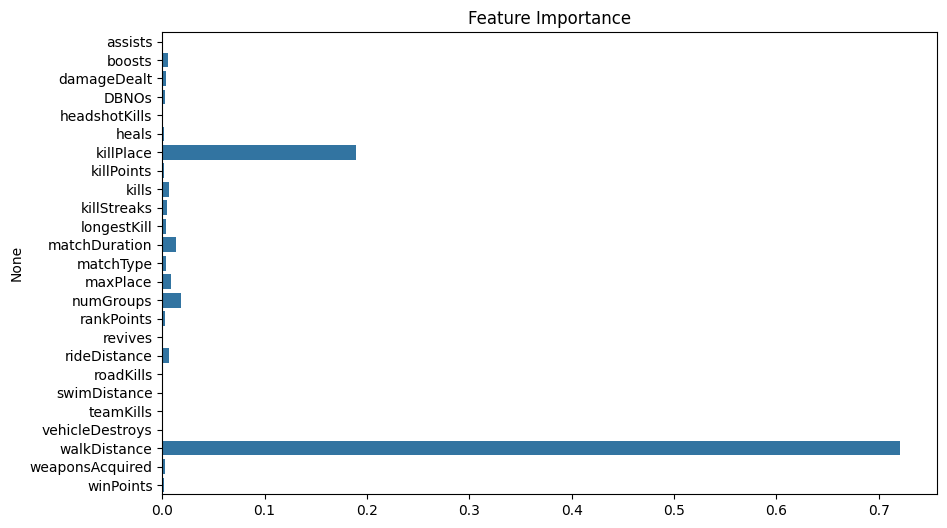

In [17]:
importance = rf.feature_importances_

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=X.columns)

plt.title("Feature Importance")
plt.show()